# Task 4 — Steps 5 & 6: Common OSR Evaluation and Failure Analysis

1. **Post-hoc scores on Vanilla** (MSP, MLS, Energy, Mahalanobis) are reloaded from notebook 2.
2. **Trained-model comparison with MLS as the common score**: Vanilla, GCSC and PROSER, plus a second PROSER row using its placeholder score. For PROSER, CSA and MLS use only the 10 known logits, so known-class classification and rejection remain separate.
3. Every row: CSA, AUROC (Known vs Near / Far / All), τ from the 95th percentile of CIFAR-10 validation unknownness, known-test acceptance, near/far rejection and FPR@95TPR.
4. **Failure analysis** with the Vanilla MLS threshold: the most confidently accepted near and far unknowns, with unknown class, predicted CIFAR-10 class, score and threshold.

Every checkpoint, score and threshold rule was fixed before this notebook, and no CIFAR-100 image influenced training or calibration.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.isdir(os.path.join(ROOT, 'task4_open_set')) and os.path.isdir('/content/task4_open_set'):
    ROOT = '/content'                    # running on a Colab server (see 0_colab_setup.ipynb)
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from shared.src.seed import set_seed, SEED
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, GROUP_COLORS, NEUTRAL, INK_2, color_of, save_show
from task4_open_set.src.data import get_cifar100_unknowns, make_loader, CIFAR10_CLASSES, NEAR_UNKNOWNS, FAR_UNKNOWNS, MEAN, STD, denorm
from task4_open_set.src.resnet_cifar import ResNetCIFAR
from task4_open_set.src.train import extract_outputs
from task4_open_set.src.scores import mls, proser_score
from task4_open_set.src.evaluate import osr_report, roc, per_class_auroc
from sklearn.manifold import TSNE

use_style()
set_seed(SEED)
device = torch.device('cuda')
T4 = os.path.join(ROOT, 'task4_open_set')
CKPT, CACHE, RES = [os.path.join(T4, d) for d in ('checkpoints', 'cache', 'results')]
near_ds, far_ds, c100_classes = get_cifar100_unknowns()
near_cls = np.array([c100_classes[t] for t in np.array(near_ds.dataset.targets)[near_ds.indices]])
far_cls = np.array([c100_classes[t] for t in np.array(far_ds.dataset.targets)[far_ds.indices]])

## 1. Outputs of the three trained models (known splits cached; unknowns extracted now)

In [2]:
OUT = {}
for key, nd in [('vanilla', 0), ('gcsc', 0), ('proser', 5)]:
    K = np.load(os.path.join(CACHE, f'{key}_known.npz'))
    upath = os.path.join(CACHE, f'{key}_unknown.npz')
    if not os.path.exists(upath):
        m = ResNetCIFAR(num_classes=10, num_dummy=nd).to(device)
        m.load_state_dict(torch.load(os.path.join(CKPT, f'{key}.pth'), map_location=device, weights_only=True))
        U = {g: extract_outputs(m, make_loader(ds, False, 512), device) for g, ds in [('near', near_ds), ('far', far_ds)]}
        np.savez_compressed(upath, **{f'{g}_{k}': v for g, o in U.items() for k, v in o.items()})
    U = np.load(upath)
    OUT[key] = {s: {f: (K if s in ('val', 'test') else U)[f'{s}_{f}'] for f in (['logits', 'feats', 'dummy'] if nd else ['logits', 'feats'])}
                for s in ['val', 'test', 'near', 'far']}
    OUT[key]['test']['labels'] = K['test_labels']
print({k: {s: v[s]['logits'].shape for s in v} for k, v in OUT.items()})

{'vanilla': {'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}, 'gcsc': {'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}, 'proser': {'val': (5000, 10), 'test': (10000, 10), 'near': (800, 10), 'far': (800, 10)}}


## 2. Table A — post-hoc scores on the frozen Vanilla model (from notebook 2)

In [3]:
tabA = pd.read_csv(os.path.join(RES, 'posthoc_scores_table.csv'), index_col=0)
tabA.drop(columns=['CSA (%)']).round(2)

,AUROC near,AUROC far,AUROC all,tau,Known test accept (%),Near reject (%),Far reject (%),FPR@95 near (%),FPR@95 far (%),FPR@95 all (%)
Vanilla score,,,,,,,,,,
MSP,81.83,89.57,85.70,0.16,94.66,31.75,44.38,68.25,55.62,61.94
MLS,80.27,89.48,84.87,-5.84,94.71,35.00,53.50,65.00,46.50,55.75
Energy,80.27,89.54,84.91,-6.03,94.58,35.00,55.00,65.00,45.00,55.00
Mahalanobis,80.06,91.36,85.71,2812.01,94.62,29.75,51.25,70.25,48.75,59.50


## 3. Table B — Vanilla vs GCSC vs PROSER

In [4]:
def u_of(key, split, score):
    o = OUT[key][split]
    return -o['logits'].max(1) if score == 'MLS' else proser_score(o['logits'], o['dummy'])
ROWS = [('Vanilla', 'vanilla', 'MLS'), ('GCSC', 'gcsc', 'MLS'), ('PROSER', 'proser', 'MLS'), ('PROSER (placeholder)', 'proser', 'placeholder')]
U_ = {}
recs = {}
for name, key, sc in ROWS:
    U_[name] = {s: u_of(key, s, sc) for s in ['val', 'test', 'near', 'far']}
    csa = (OUT[key]['test']['logits'].argmax(1) == OUT[key]['test']['labels']).mean()
    recs[name] = {'score': sc, **osr_report(U_[name]['val'], U_[name]['test'], U_[name]['near'], U_[name]['far'], csa)}
tabB = pd.DataFrame(recs).T
for c in tabB.columns:
    if c != 'score': tabB[c] = tabB[c].astype(float)
tabB.to_csv(os.path.join(RES, 'model_comparison_table.csv'))
tabB.round(2)

,score,CSA (%),AUROC near,AUROC far,AUROC all,tau,Known test accept (%),Near reject (%),Far reject (%),FPR@95 near (%),FPR@95 far (%),FPR@95 all (%)
Vanilla,MLS,94.81,80.27,89.48,84.87,-5.84,94.71,35.00,53.50,65.00,46.50,55.75
GCSC,MLS,94.95,81.41,90.22,85.81,-6.22,94.93,31.37,55.38,68.62,44.62,56.62
PROSER,MLS,94.35,80.09,87.46,83.78,-4.98,94.67,32.00,48.50,68.00,51.50,59.75
PROSER (placeholder),placeholder,94.35,78.52,88.27,83.40,0.62,94.75,32.00,51.75,68.00,48.25,58.13


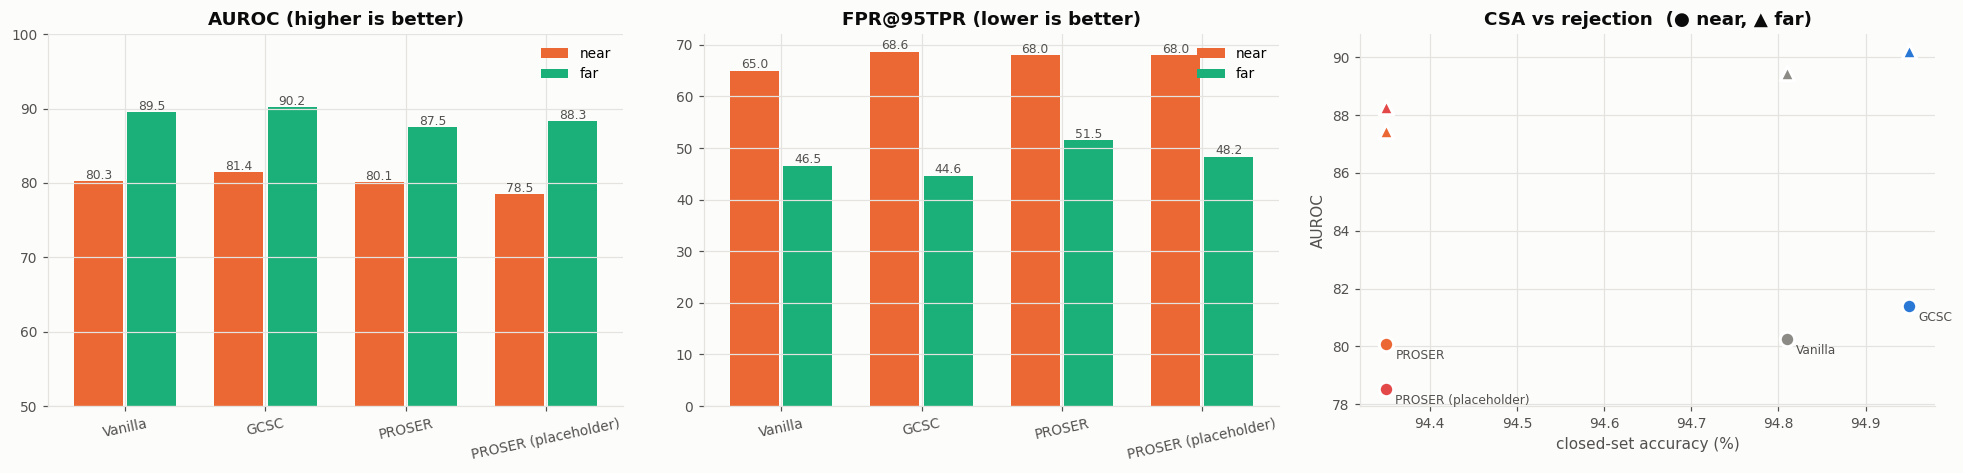

In [5]:
names = [r[0] for r in ROWS]; x = np.arange(len(names))
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
w = 0.38
for k, g in enumerate(['near', 'far']):
    b = ax[0].bar(x + (k - 0.5) * w, tabB[f'AUROC {g}'].astype(float), w * 0.92, color=GROUP_COLORS[g.capitalize()], label=g)
    for bb in b: ax[0].text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.3, f'{bb.get_height():.1f}', ha='center', fontsize=8, color=INK_2)
    b = ax[1].bar(x + (k - 0.5) * w, tabB[f'FPR@95 {g} (%)'].astype(float), w * 0.92, color=GROUP_COLORS[g.capitalize()], label=g)
    for bb in b: ax[1].text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.5, f'{bb.get_height():.1f}', ha='center', fontsize=8, color=INK_2)
ax[0].set_ylim(50, 100); ax[0].set_title('AUROC (higher is better)'); ax[1].set_title('FPR@95TPR (lower is better)')
for a in ax[:2]: a.set_xticks(x); a.set_xticklabels(names, rotation=12); a.legend()
for n in names:
    ax[2].scatter(float(tabB.loc[n, 'CSA (%)']), float(tabB.loc[n, 'AUROC near']), s=90, marker='o', color=color_of(n), edgecolor='white', linewidth=2, zorder=3)
    ax[2].scatter(float(tabB.loc[n, 'CSA (%)']), float(tabB.loc[n, 'AUROC far']), s=90, marker='^', color=color_of(n), edgecolor='white', linewidth=2, zorder=3)
    ax[2].annotate(n, (float(tabB.loc[n, 'CSA (%)']), float(tabB.loc[n, 'AUROC near'])), xytext=(6, -10), textcoords='offset points', fontsize=8, color=INK_2)
ax[2].set_xlabel('closed-set accuracy (%)'); ax[2].set_ylabel('AUROC'); ax[2].set_title('CSA vs rejection  (● near, ▲ far)')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'model_comparison_bars.png'))

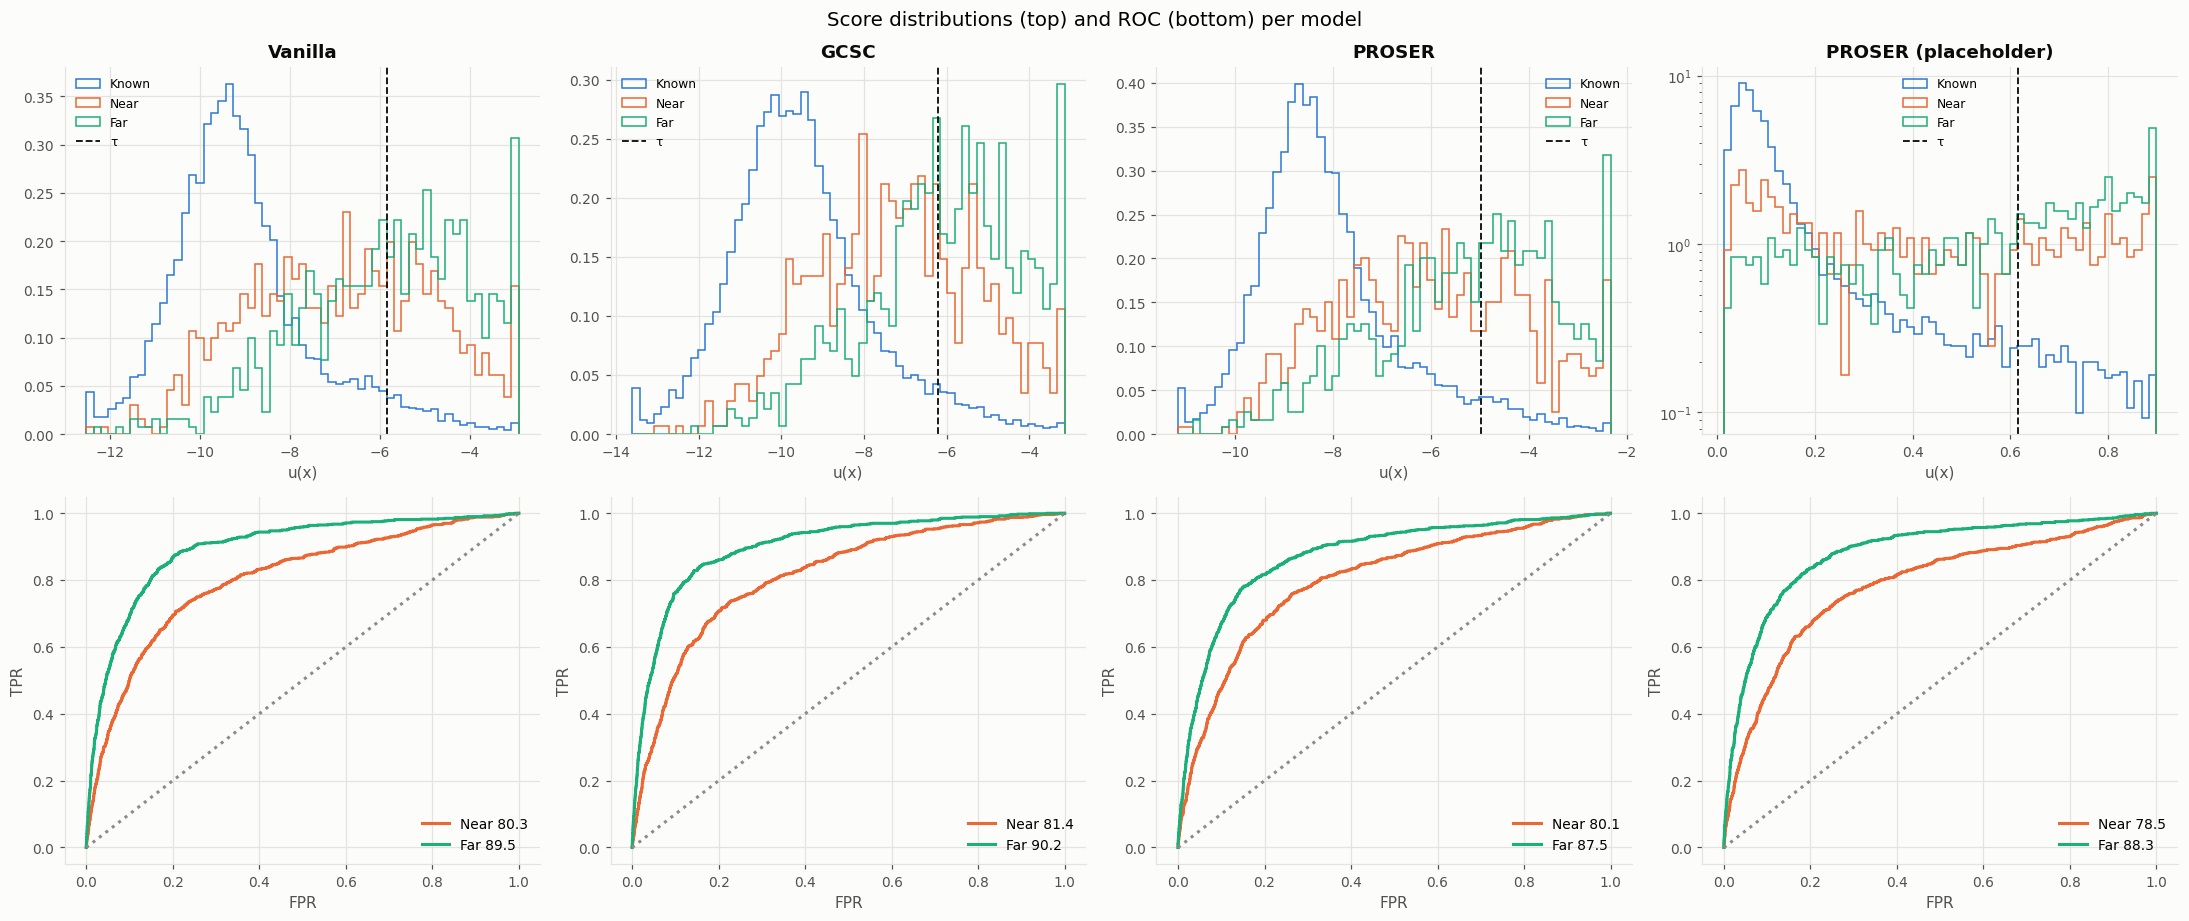

In [6]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8.5))
for j, n in enumerate(names):
    u = U_[n]; tau = float(tabB.loc[n, 'tau'])
    vals = np.concatenate([u['test'], u['near'], u['far']]); lo, hi = np.percentile(vals, 0.5), np.percentile(vals, 99.5)
    bins = np.linspace(lo, hi, 60)
    for g, key in [('Known', 'test'), ('Near', 'near'), ('Far', 'far')]:
        ax[0, j].hist(np.clip(u[key], lo, hi), bins=bins, histtype='step', lw=1.8, color=GROUP_COLORS[g], density=True, label=g)
    ax[0, j].axvline(tau, color='#0b0b0b', ls='--', lw=1.2, label='τ')
    if 'placeholder' in n: ax[0, j].set_yscale('log')
    ax[0, j].set_title(n); ax[0, j].set_xlabel('u(x)'); ax[0, j].legend(fontsize=8)
    for g, key in [('Near', 'near'), ('Far', 'far')]:
        fpr, tpr = roc(u['test'], u[key]); ax[1, j].plot(fpr, tpr, color=GROUP_COLORS[g], label=f"{g} {float(tabB.loc[n, f'AUROC {key}']):.1f}")
    ax[1, j].plot([0, 1], [0, 1], ':', color=NEUTRAL); ax[1, j].legend(loc='lower right'); ax[1, j].set_xlabel('FPR'); ax[1, j].set_ylabel('TPR')
fig.suptitle('Score distributions (top) and ROC (bottom) per model', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'model_comparison_distributions_roc.png'))

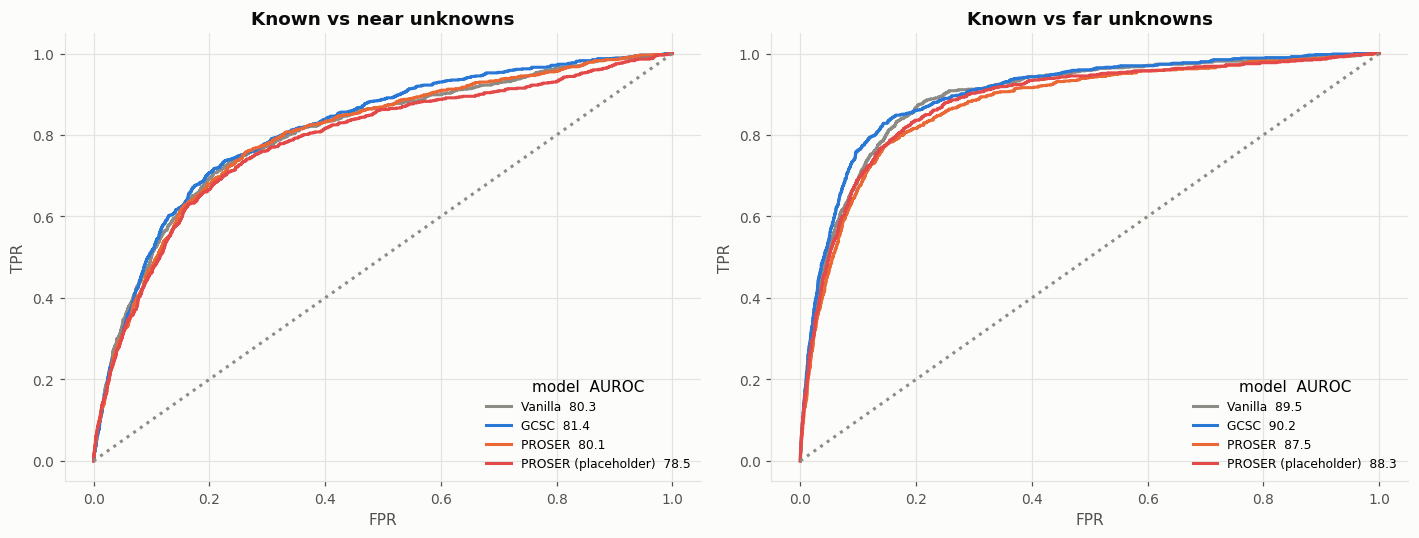

In [7]:
# All four rows on one ROC axis per unknown group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key in zip(axes, ['near', 'far']):
    for n in names:
        fpr, tpr = roc(U_[n]['test'], U_[n][key]); ax.plot(fpr, tpr, color=color_of(n), label=f"{n}  {tabB.loc[n, f'AUROC {key}']:.1f}")
    ax.plot([0, 1], [0, 1], ':', color=NEUTRAL); ax.set_title(f'Known vs {key} unknowns'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', title='model  AUROC', fontsize=8)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'model_comparison_roc_overlay.png'))

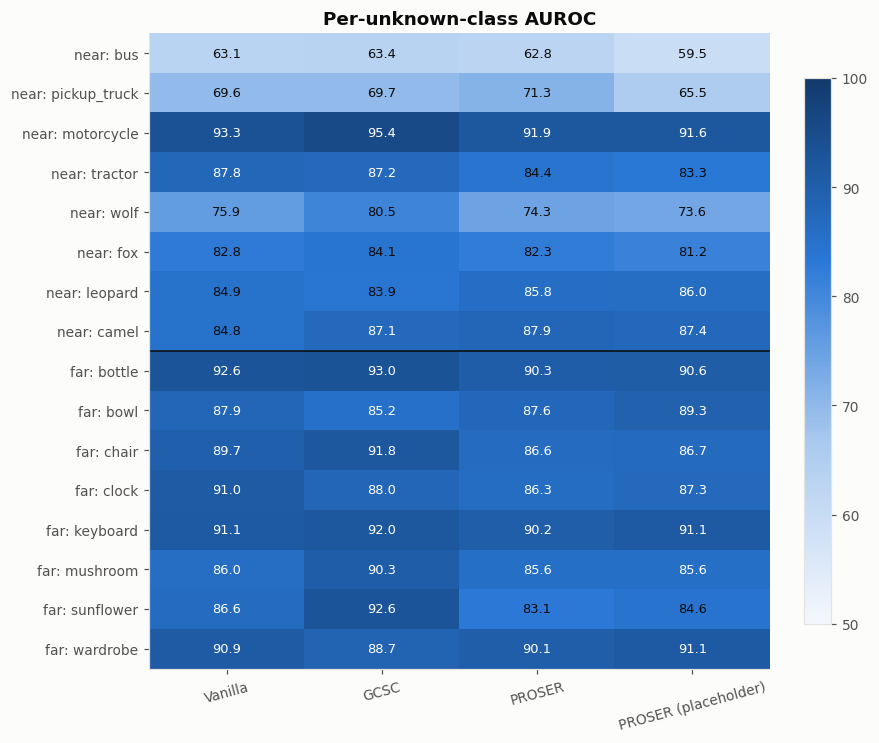

,bus,pickup_truck,motorcycle,tractor,wolf,fox,leopard,camel,bottle,bowl,chair,clock,keyboard,mushroom,sunflower,wardrobe
Vanilla,63.1,69.6,93.3,87.8,75.9,82.8,84.9,84.8,92.6,87.9,89.7,91.0,91.1,86.0,86.6,90.9
GCSC,63.4,69.7,95.4,87.2,80.5,84.1,83.9,87.1,93.0,85.2,91.8,88.0,92.0,90.3,92.6,88.7
PROSER,62.8,71.3,91.9,84.4,74.3,82.3,85.8,87.9,90.3,87.6,86.6,86.3,90.2,85.6,83.1,90.1
PROSER (placeholder),59.5,65.5,91.6,83.3,73.6,81.2,86.0,87.4,90.6,89.3,86.7,87.3,91.1,85.6,84.6,91.1


In [8]:
# Per-unknown-class AUROC for every model row
pcau = pd.DataFrame({n: {**per_class_auroc(U_[n]['test'], U_[n]['near'], near_cls), **per_class_auroc(U_[n]['test'], U_[n]['far'], far_cls)} for n in names}).loc[NEAR_UNKNOWNS + FAR_UNKNOWNS]
fig, a = plt.subplots(figsize=(8, 7.5))
im = a.imshow(pcau.values, cmap=SEQ_CMAP, vmin=50, vmax=100, aspect='auto')
for i in range(16):
    for j in range(len(names)): a.text(j, i, f'{pcau.values[i, j]:.1f}', ha='center', va='center', fontsize=8.5, color='white' if pcau.values[i, j] > 85 else '#0b0b0b')
a.set_xticks(range(len(names))); a.set_xticklabels(names, rotation=15); a.set_yticks(range(16)); a.set_yticklabels([f'near: {c}' for c in NEAR_UNKNOWNS] + [f'far: {c}' for c in FAR_UNKNOWNS])
a.axhline(7.5, color='#0b0b0b', lw=1); a.grid(False); a.set_title('Per-unknown-class AUROC'); fig.colorbar(im, ax=a, fraction=0.04)
save_show(fig, os.path.join(RES, 'model_comparison_per_class_auroc.png'))
pcau.round(1).T

## 4. Per-unknown-class acceptance across models

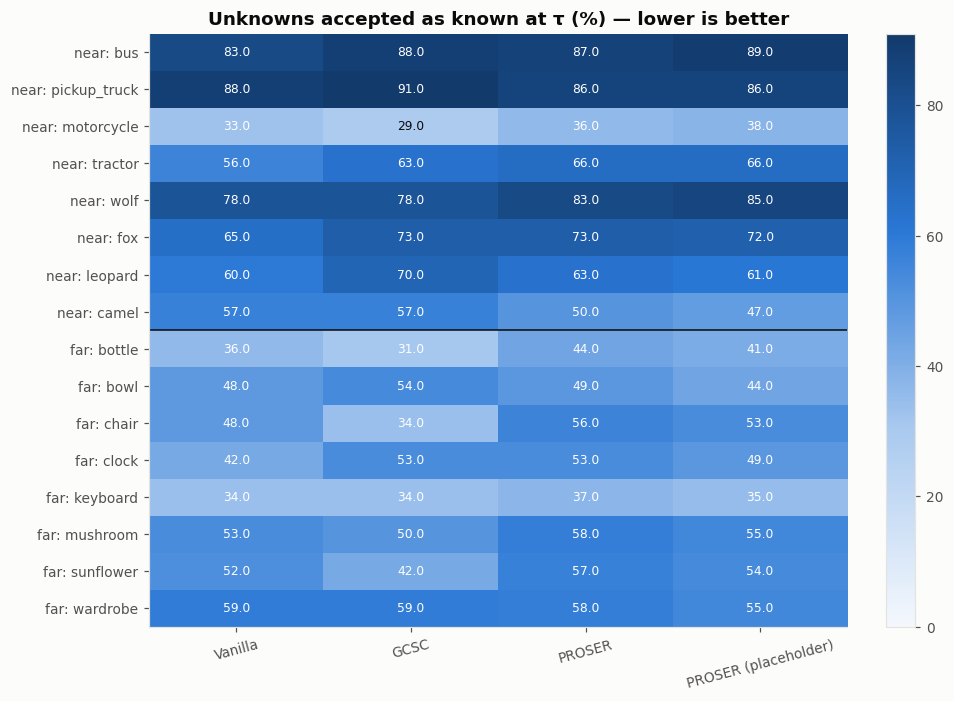

In [9]:
rows = []
for n in names:
    tau = float(tabB.loc[n, 'tau'])
    for g, cls in [('near', near_cls), ('far', far_cls)]:
        for c in (NEAR_UNKNOWNS if g == 'near' else FAR_UNKNOWNS):
            rows.append({'model': n, 'group': g, 'class': c, 'accepted (%)': 100 * (U_[n][g][cls == c] <= tau).mean()})
pa = pd.DataFrame(rows).pivot_table(index=['group', 'class'], columns='model', values='accepted (%)')[names]
pa = pa.reindex([('near', c) for c in NEAR_UNKNOWNS] + [('far', c) for c in FAR_UNKNOWNS])
fig, a = plt.subplots(figsize=(9, 7))
im = a.imshow(pa.values, cmap=SEQ_CMAP, vmin=0, vmax=max(40, pa.values.max()), aspect='auto')
for i in range(pa.shape[0]):
    for j in range(pa.shape[1]): a.text(j, i, f'{pa.values[i, j]:.1f}', ha='center', va='center', fontsize=8, color='white' if pa.values[i, j] > 30 else '#0b0b0b')
a.set_xticks(range(len(names))); a.set_xticklabels(names, rotation=15); a.set_yticks(range(16)); a.set_yticklabels([f'{g}: {c}' for g, c in pa.index])
a.axhline(7.5, color='#0b0b0b', lw=1); a.grid(False); a.set_title('Unknowns accepted as known at τ (%) — lower is better'); fig.colorbar(im, ax=a, fraction=0.04)
save_show(fig, os.path.join(RES, 'model_comparison_per_class_acceptance.png'))

### Feature space of each model with unknowns overlaid
One t-SNE per model (seed 6304) on 1,500 known test images (colour = class) plus 400 near (▲) and 400 far (■) unknowns. Coordinates are not comparable across panels.

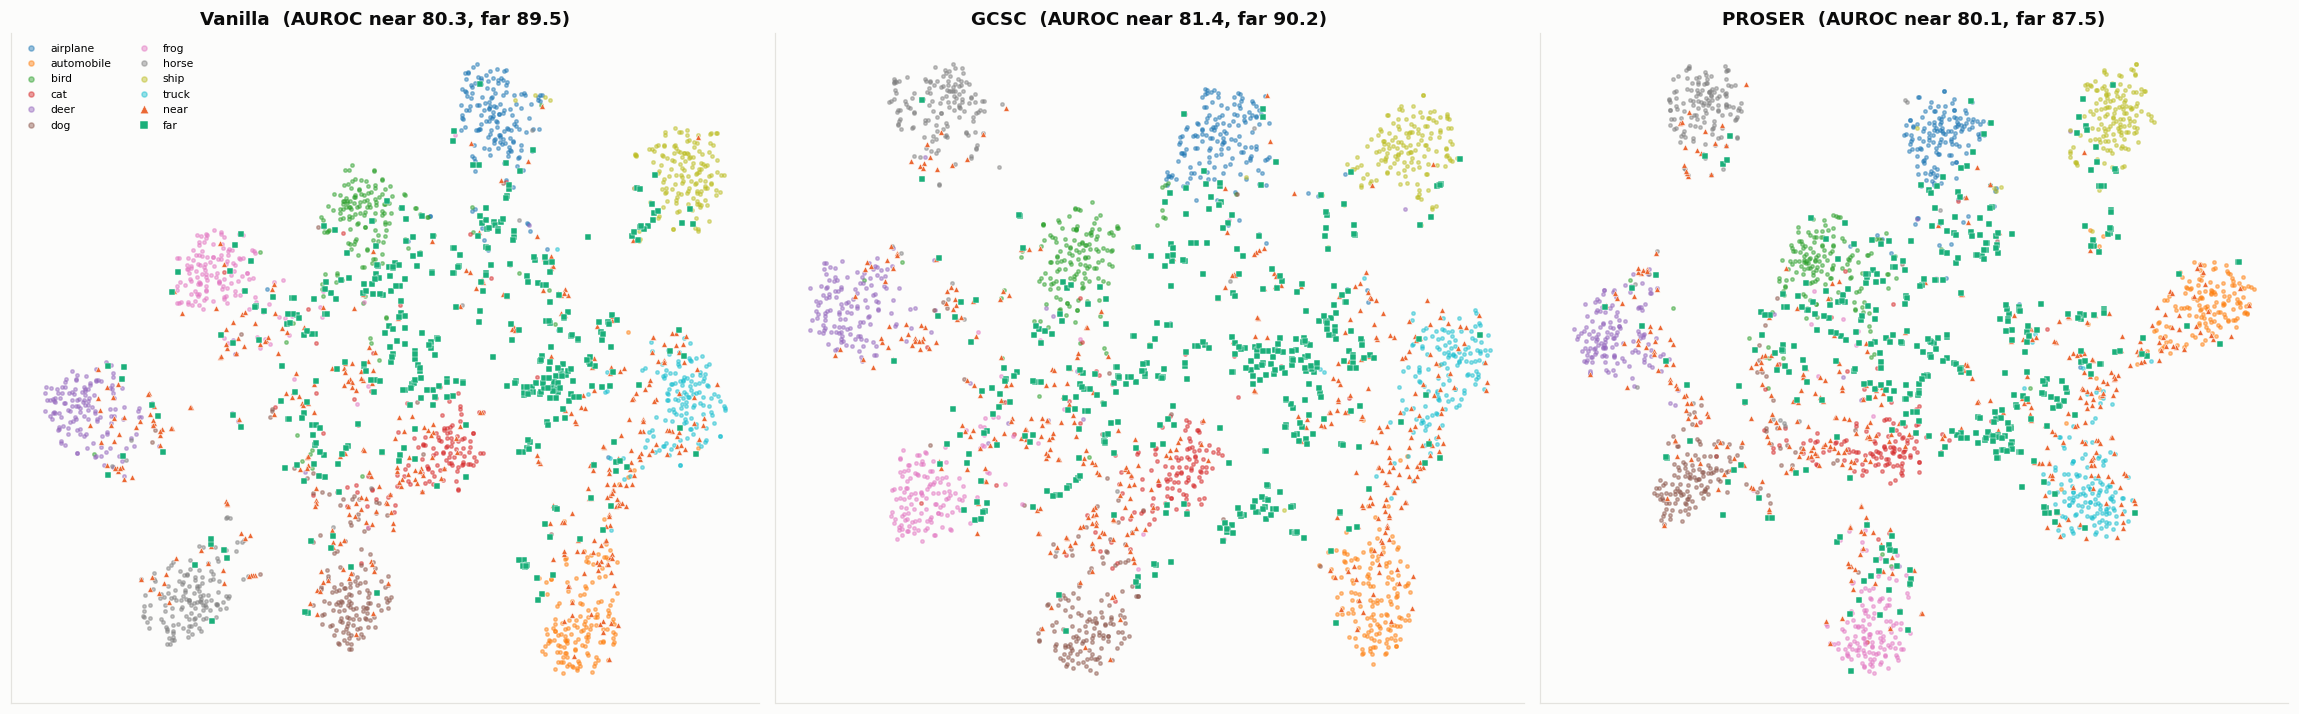

In [10]:
rng = np.random.RandomState(SEED)
kt = rng.choice(10000, 1500, replace=False); nt = rng.choice(800, 400, replace=False); ft = rng.choice(800, 400, replace=False)
cmap10 = plt.get_cmap('tab10')
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
for ax, (n, key) in zip(axes, [('Vanilla', 'vanilla'), ('GCSC', 'gcsc'), ('PROSER', 'proser')]):
    X = np.concatenate([OUT[key]['test']['feats'][kt], OUT[key]['near']['feats'][nt], OUT[key]['far']['feats'][ft]])
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(X); yk = OUT[key]['test']['labels'][kt]
    for c in range(10):
        s = yk == c; ax.scatter(E[:1500][s, 0], E[:1500][s, 1], s=5, alpha=0.45, color=cmap10(c), label=CIFAR10_CLASSES[c])
    ax.scatter(E[1500:1900, 0], E[1500:1900, 1], s=14, marker='^', color=GROUP_COLORS['Near'], edgecolors='white', linewidths=0.3, label='near')
    ax.scatter(E[1900:, 0], E[1900:, 1], s=14, marker='s', color=GROUP_COLORS['Far'], edgecolors='white', linewidths=0.3, label='far')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{n}  (AUROC near {tabB.loc[n, 'AUROC near']:.1f}, far {tabB.loc[n, 'AUROC far']:.1f})")
axes[0].legend(fontsize=7, ncol=2, markerscale=1.5); fig.tight_layout()
save_show(fig, os.path.join(RES, 'model_comparison_tsne.png'))

## 5. Failure analysis — incorrectly accepted unknowns (Vanilla, MLS threshold)
The six most confidently accepted near unknowns and the six most confidently accepted far unknowns (lowest $u_{\text{MLS}}$, all below τ). Each is tagged **semantically plausible** or **surprising** using a mapping fixed *a priori* from class semantics (e.g. wolf/fox → dog, leopard → cat, camel → horse/deer, bus/pickup truck/tractor → truck/automobile), not from the results.

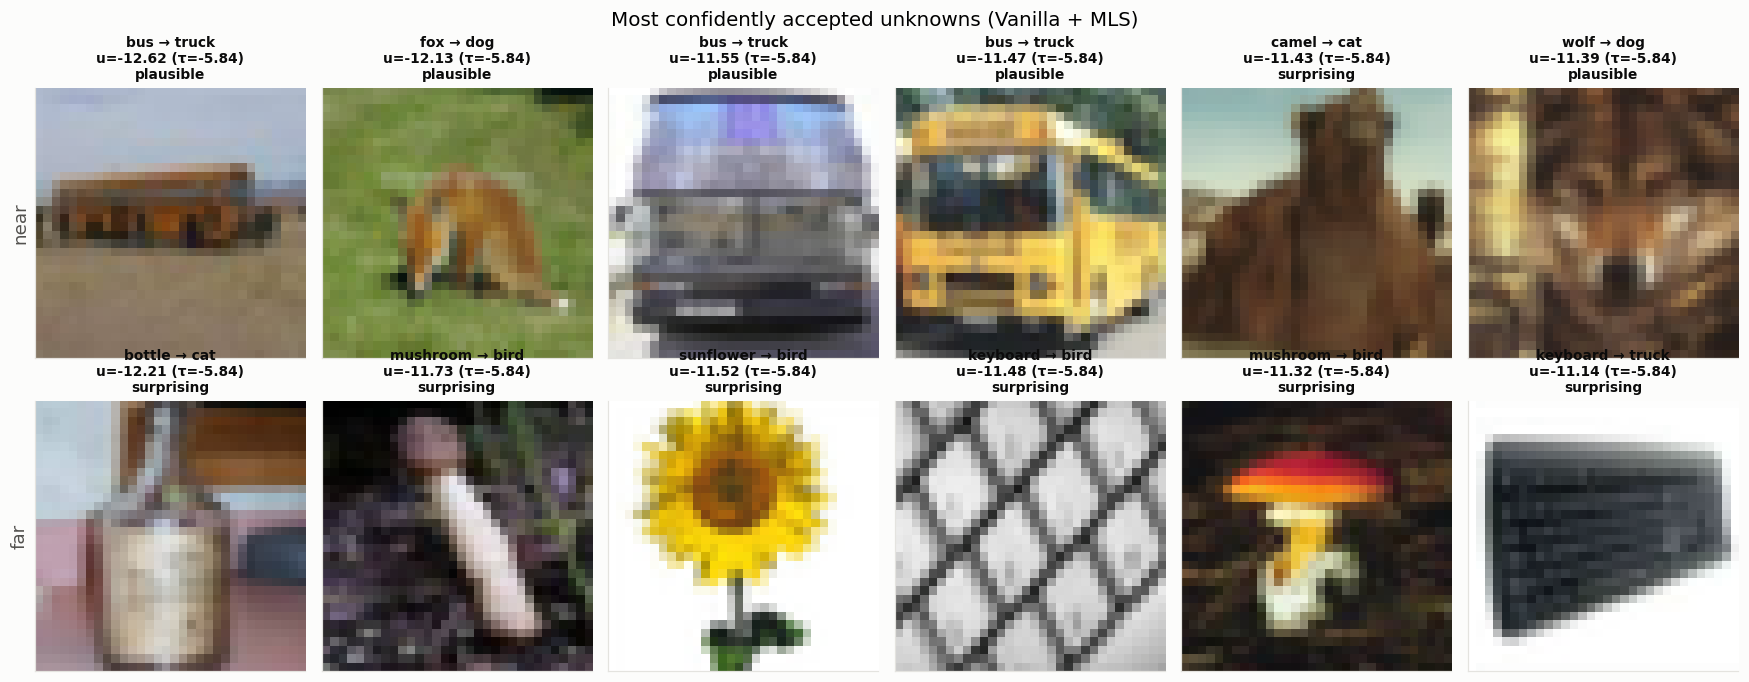

,group,unknown class,predicted CIFAR-10,u_MLS,max logit,tau,judgement
0,near,bus,truck,-12.618,12.618,-5.837,plausible
1,near,fox,dog,-12.134,12.134,-5.837,plausible
2,near,bus,truck,-11.546,11.546,-5.837,plausible
3,near,bus,truck,-11.474,11.474,-5.837,plausible
4,near,camel,cat,-11.434,11.434,-5.837,surprising
5,near,wolf,dog,-11.385,11.385,-5.837,plausible
6,far,bottle,cat,-12.212,12.212,-5.837,surprising
7,far,mushroom,bird,-11.727,11.727,-5.837,surprising
8,far,sunflower,bird,-11.524,11.524,-5.837,surprising
9,far,keyboard,bird,-11.484,11.484,-5.837,surprising


In [11]:
PLAUSIBLE = {'wolf': {'dog', 'deer', 'cat'}, 'fox': {'dog', 'cat', 'deer'}, 'leopard': {'cat', 'deer', 'dog'}, 'camel': {'horse', 'deer'},
             'bus': {'truck', 'automobile'}, 'pickup_truck': {'truck', 'automobile'}, 'tractor': {'truck', 'automobile'}, 'motorcycle': {'automobile', 'truck'},
             'bottle': set(), 'bowl': set(), 'chair': set(), 'clock': set(), 'keyboard': set(), 'mushroom': set(), 'sunflower': set(), 'wardrobe': set()}
tau_v = float(tabB.loc['Vanilla', 'tau'])
mean, std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
fail_rows = []
fig, axes = plt.subplots(2, 6, figsize=(16, 6.4))
for r, (g, ds, cls) in enumerate([('near', near_ds, near_cls), ('far', far_ds, far_cls)]):
    u = U_['Vanilla'][g]; pred = OUT['vanilla'][g]['logits'].argmax(1)
    for c, i in enumerate(np.argsort(u)[:6]):
        pc = CIFAR10_CLASSES[pred[i]]; tag = 'plausible' if pc in PLAUSIBLE[cls[i]] else 'surprising'
        fail_rows.append({'group': g, 'unknown class': cls[i], 'predicted CIFAR-10': pc, 'u_MLS': u[i], 'max logit': -u[i], 'tau': tau_v, 'judgement': tag})
        ax = axes[r, c]; ax.imshow((ds[int(i)][0] * std + mean).clamp(0, 1).permute(1, 2, 0)); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f'{cls[i]} → {pc}\nu={u[i]:.2f} (τ={tau_v:.2f})\n{tag}', fontsize=9)
    axes[r, 0].set_ylabel(g, fontsize=12)
fig.suptitle('Most confidently accepted unknowns (Vanilla + MLS)', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'failure_cases_vanilla_mls.png'))
fails = pd.DataFrame(fail_rows); fails.to_csv(os.path.join(RES, 'failure_cases_vanilla_mls.csv'), index=False)
fails.round(3)

In [12]:
# Aggregate view: among ALL unknowns accepted by Vanilla+MLS, how often is the confusion semantically plausible?
for g, cls in [('near', near_cls), ('far', far_cls)]:
    u = U_['Vanilla'][g]; pred = OUT['vanilla'][g]['logits'].argmax(1); acc = u <= tau_v
    plaus = np.array([CIFAR10_CLASSES[p] in PLAUSIBLE[c] for p, c in zip(pred, cls)])
    print(f"{g}: {acc.sum()} accepted of 800 | plausible confusions among accepted: {100*plaus[acc].mean() if acc.any() else float('nan'):.1f}% "
          f"| most common absorbing label: {pd.Series(np.array(CIFAR10_CLASSES)[pred[acc]]).value_counts().head(3).to_dict()}")

near: 520 accepted of 800 | plausible confusions among accepted: 83.5% | most common absorbing label: {'truck': 155, 'automobile': 91, 'cat': 81}
far: 372 accepted of 800 | plausible confusions among accepted: 0.0% | most common absorbing label: {'bird': 84, 'cat': 76, 'truck': 70}


### The same failure view for GCSC and PROSER
For each model and its own threshold: the 4 most confidently accepted near unknowns and the 4 most confidently accepted far unknowns.

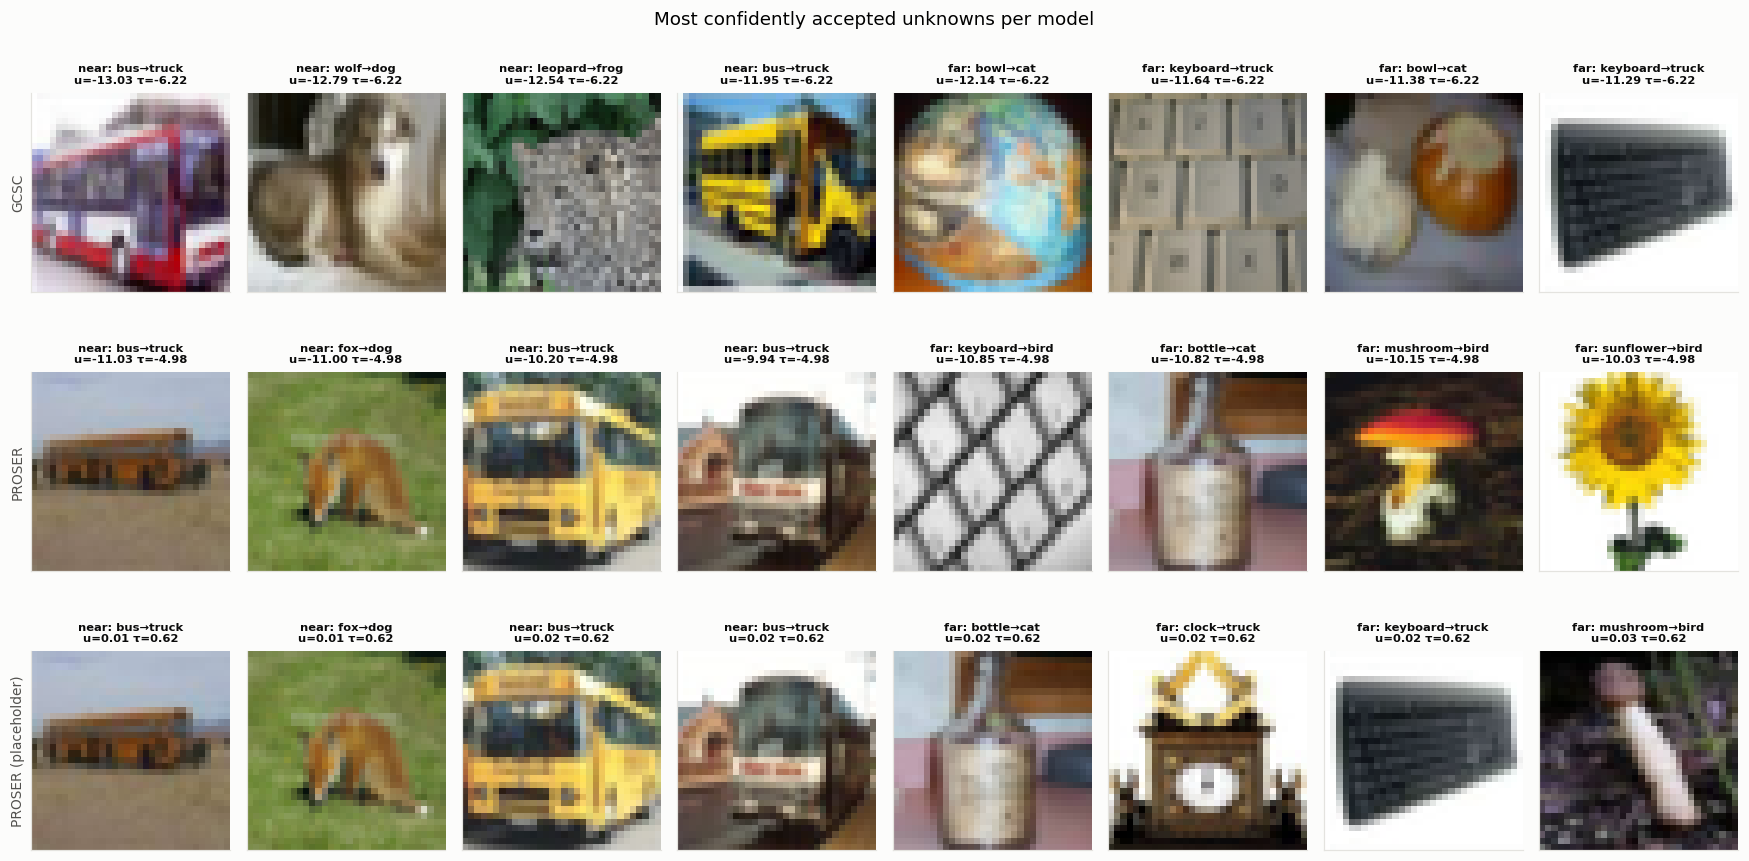

In [13]:
rows_m = [('GCSC', 'gcsc', 'GCSC'), ('PROSER', 'proser', 'PROSER'), ('PROSER (placeholder)', 'proser', 'PROSER (placeholder)')]
fig, axes = plt.subplots(len(rows_m), 8, figsize=(16, 2.6 * len(rows_m) + 0.6))
for r, (n, key, row) in enumerate(rows_m):
    tau = float(tabB.loc[row, 'tau'])
    for k, (g, ds, cls) in enumerate([('near', near_ds, near_cls), ('far', far_ds, far_cls)]):
        u = U_[row][g]; pred = OUT[key][g]['logits'].argmax(1)
        for c, i in enumerate(np.argsort(u)[:4]):
            ax = axes[r, 4 * k + c]; ax.imshow(denorm(ds[int(i)][0])); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            ax.set_title(f'{g}: {cls[i]}→{CIFAR10_CLASSES[pred[i]]}\nu={u[i]:.2f} τ={tau:.2f}', fontsize=7.5)
    axes[r, 0].set_ylabel(n, fontsize=9)
fig.suptitle('Most confidently accepted unknowns per model', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'failure_cases_all_models.png'))

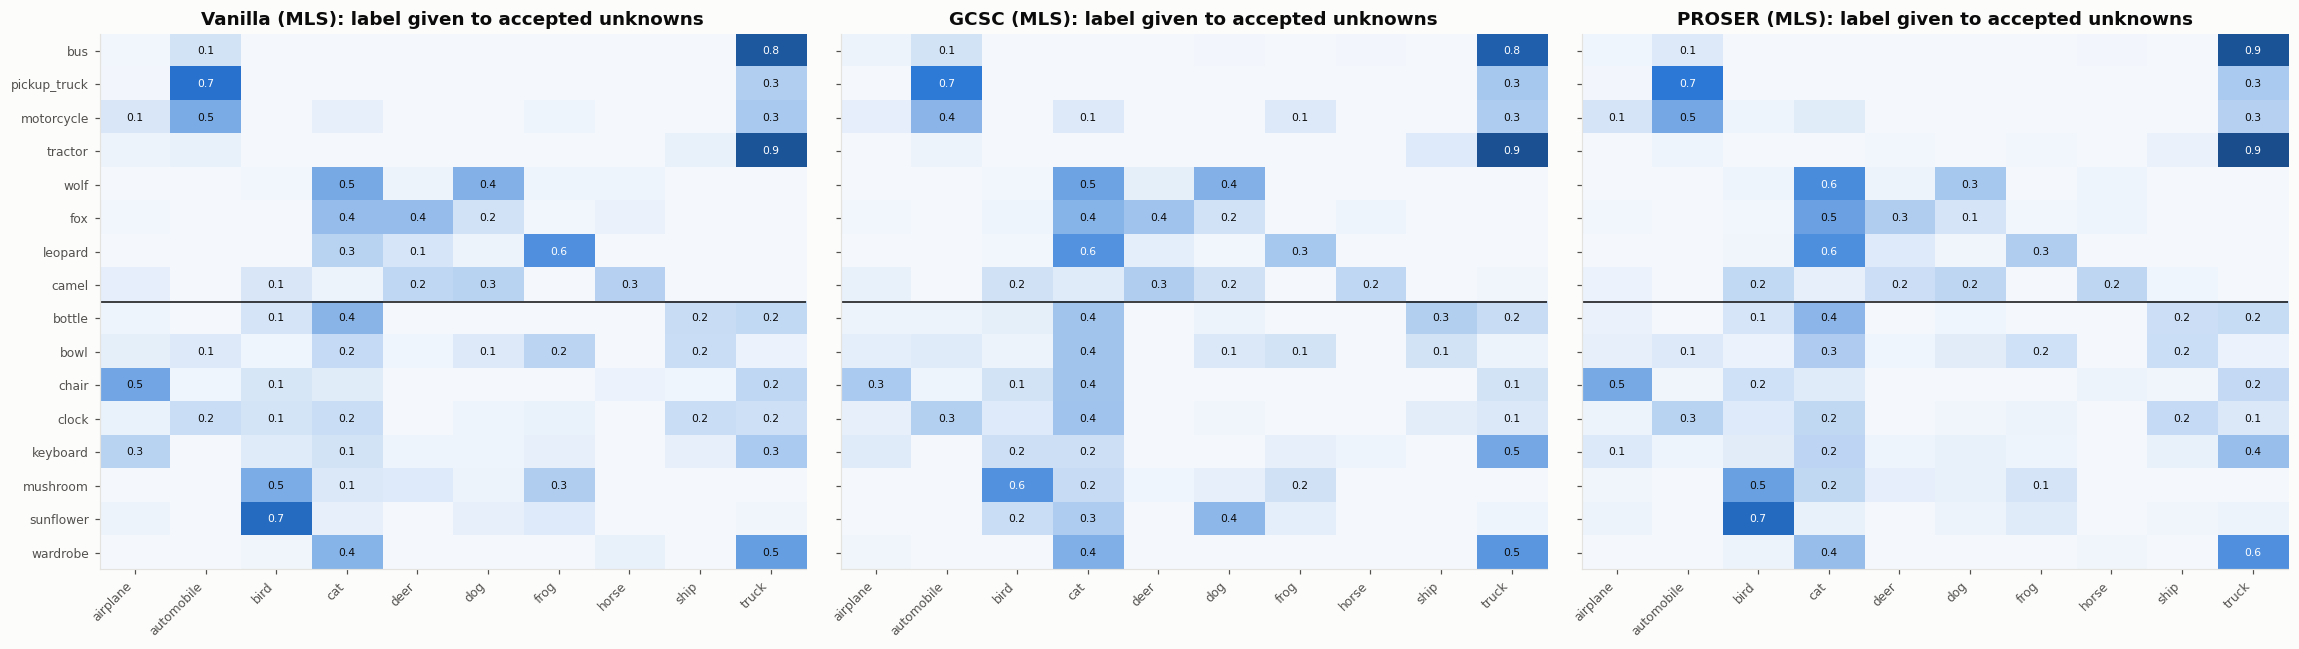

In [14]:
# Which CIFAR-10 labels absorb the accepted unknowns, per model (row share of accepted images)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (n, key) in zip(axes, [('Vanilla', 'vanilla'), ('GCSC', 'gcsc'), ('PROSER', 'proser')]):
    tau = float(tabB.loc[n, 'tau']); A = []
    for g, cls in [('near', near_cls), ('far', far_cls)]:
        acc = U_[n][g] <= tau; pred = OUT[key][g]['logits'].argmax(1)
        for c in (NEAR_UNKNOWNS if g == 'near' else FAR_UNKNOWNS):
            s = acc & (cls == c); A.append(np.bincount(pred[s], minlength=10) / max(1, s.sum()))
    A = np.array(A); ax.imshow(A, cmap=SEQ_CMAP, vmin=0, vmax=1, aspect='auto')
    for i in range(16):
        for j in range(10):
            if A[i, j] >= 0.1: ax.text(j, i, f'{A[i, j]:.1f}', ha='center', va='center', fontsize=7, color='white' if A[i, j] > 0.55 else '#0b0b0b')
    ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right', fontsize=8); ax.set_yticks(range(16))
    ax.set_yticklabels(NEAR_UNKNOWNS + FAR_UNKNOWNS if n == 'Vanilla' else [], fontsize=8); ax.axhline(7.5, color='#0b0b0b', lw=1); ax.grid(False)
    ax.set_title(f'{n} (MLS): label given to accepted unknowns')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'model_comparison_absorbing_labels.png'))

## 6. Positive augmentation (GCSC) vs placeholders (PROSER) — evidence summary
The numbers below compare changes in closed-set accuracy with changes in near/far rejection relative to Vanilla (all MLS unless marked). Interpretation belongs in the report.

In [15]:
base = tabB.loc['Vanilla']
cmp = pd.DataFrame({n: {'Δ CSA (pp)': float(tabB.loc[n, 'CSA (%)']) - float(base['CSA (%)']),
                        'Δ AUROC near': float(tabB.loc[n, 'AUROC near']) - float(base['AUROC near']),
                        'Δ AUROC far': float(tabB.loc[n, 'AUROC far']) - float(base['AUROC far']),
                        'Δ near reject (pp)': float(tabB.loc[n, 'Near reject (%)']) - float(base['Near reject (%)']),
                        'Δ far reject (pp)': float(tabB.loc[n, 'Far reject (%)']) - float(base['Far reject (%)'])} for n in names[1:]}).T
cmp.to_csv(os.path.join(RES, 'model_comparison_deltas.csv'))
cmp.round(2)

,Δ CSA (pp),Δ AUROC near,Δ AUROC far,Δ near reject (pp),Δ far reject (pp)
GCSC,0.14,1.14,0.74,-3.63,1.88
PROSER,-0.46,-0.18,-2.01,-3.00,-5.00
PROSER (placeholder),-0.46,-1.75,-1.20,-3.00,-1.75
